In [1]:
import os
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [2]:
start_year = 2004
end_year = start_year
pred_file = f'../results/{start_year}-{end_year}/hdpsm_nrep10_mratio5_drug_reaction_associations.csv'

In [10]:
preds = pd.read_csv(pred_file)
preds['reaction'] = preds['reaction'].str.lower()
preds['mean'] = preds['a']/(preds['a']+preds['b'])
preds.head()

,drug,reaction,patient_sex,replicate,a,b,c,d,OR,PRR,PHI,mean
0,sufentanil,myocardial ischaemia,All,0,11,31,3,175,20.698925,15.539683,0.394542,0.261905
1,sufentanil,post procedural complication,All,0,11,31,19,159,2.969440,2.453634,0.177699,0.261905
2,sufentanil,bradycardia,All,0,5,37,9,169,2.537538,2.354497,0.110265,0.119048
3,sufentanil,drug interaction,All,0,6,36,15,163,1.811111,1.695238,0.078362,0.142857
4,sufentanil,hypotension,All,0,5,37,10,168,2.270270,2.119048,0.098026,0.119048


In [11]:
# positive controls
fn = '../data/onsides_public_warnings_and_precautions.csv'
positive_df = pd.read_csv(fn)
positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()

,ingredients_rxcuis,drug,pt_meddra_id,reaction,label
0,321988,escitalopram,10012218,delirium,1
1,1364347,ponatinib,10003668,atrial tachycardia,1
2,4493,fluoxetine,10025197,lymphadenopathy,1
3,4099,"estrogens, conjugated (USP)",10016807,fluid retention,1
4,753340,sapropterin,10037211,psychomotor hyperactivity,1


In [12]:
merged = pd.merge(preds, positive_df, on=['drug', 'reaction'], how='left')
merged['label'] = merged['label'].fillna(0)
merged.head()

,drug,reaction,patient_sex,replicate,a,b,c,d,OR,PRR,PHI,mean,ingredients_rxcuis,pt_meddra_id,label
0,sufentanil,myocardial ischaemia,All,0,11,31,3,175,20.698925,15.539683,0.394542,0.261905,NaN,NaN,0.0
1,sufentanil,post procedural complication,All,0,11,31,19,159,2.969440,2.453634,0.177699,0.261905,NaN,NaN,0.0
2,sufentanil,bradycardia,All,0,5,37,9,169,2.537538,2.354497,0.110265,0.119048,56795.0,10006093.0,1.0
3,sufentanil,drug interaction,All,0,6,36,15,163,1.811111,1.695238,0.078362,0.142857,NaN,NaN,0.0
4,sufentanil,hypotension,All,0,5,37,10,168,2.270270,2.119048,0.098026,0.119048,56795.0,10021097.0,1.0


0.6505283414581003
0.14095988365909196


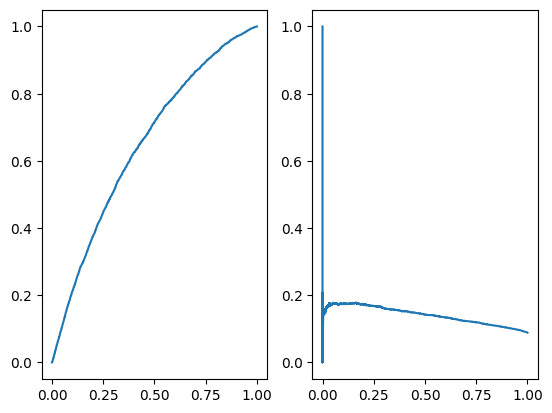

In [14]:
col = 'mean'

print(metrics.roc_auc_score(merged['label'], merged[col]))
print(metrics.average_precision_score(merged['label'], merged[col]))
fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)
plt.subplot(1,2,1)
plt.plot(fpr, tpr)

pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
plt.subplot(1,2,2)
plt.plot(re, pr)
